In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

ROOT = Path.cwd().parent
df = pd.read_csv(ROOT / "data" / "processed" / "harga_pangan_manado_long.csv",
                 parse_dates=["tanggal"])
varian = df[df["level"] == "varian"].copy()

TARGET = "Cabai Rawit Merah"
seri = (
    varian[varian["komoditas"] == TARGET]
    .sort_values("tanggal")
    .set_index("tanggal")["harga"]
    .astype(float)
)

print(f"Komoditas : {TARGET}")
print(f"Observasi : {len(seri)}")
print(f"Periode   : {seri.index.min():%d %b %Y} s/d {seri.index.max():%d %b %Y}")
seri.tail()

Komoditas : Cabai Rawit Merah
Observasi : 440
Periode   : 01 Jan 2025 s/d 08 Sep 2026


tanggal
2026-09-02    115000.0
2026-09-03    115000.0
2026-09-04    112500.0
2026-09-07    165000.0
2026-09-08    165000.0
Name: harga, dtype: float64

In [2]:
def mae(aktual, prediksi):
    return np.mean(np.abs(aktual - prediksi))

def mape(aktual, prediksi):
    return np.mean(np.abs((aktual - prediksi) / aktual)) * 100

# pisah: 80% latih, 20% uji — berurutan waktu, tanpa acak
batas = int(len(seri) * 0.8)
latih, uji = seri.iloc[:batas], seri.iloc[batas:]

print(f"Latih: {len(latih)} obs, {latih.index.min():%d %b %Y} s/d {latih.index.max():%d %b %Y}")
print(f"Uji  : {len(uji)} obs, {uji.index.min():%d %b %Y} s/d {uji.index.max():%d %b %Y}\n")

hasil_baseline = {}

# Baseline 1: naive — prediksi = harga kemarin
pred_naive = seri.shift(1).loc[uji.index]
hasil_baseline["Naive (harga kemarin)"] = (mae(uji, pred_naive), mape(uji, pred_naive))

# Baseline 2: rata-rata bergerak 7 hari
pred_ma7 = seri.shift(1).rolling(7).mean().loc[uji.index]
hasil_baseline["Rata-rata 7 hari"] = (mae(uji, pred_ma7), mape(uji, pred_ma7))

# Baseline 3: rata-rata seluruh data latih
pred_mean = pd.Series(latih.mean(), index=uji.index)
hasil_baseline["Rata-rata global"] = (mae(uji, pred_mean), mape(uji, pred_mean))

tabel = pd.DataFrame(hasil_baseline, index=["MAE (Rp)", "MAPE (%)"]).T.round(2)
print(tabel.to_string())

Latih: 352 obs, 01 Jan 2025 s/d 07 May 2026
Uji  : 88 obs, 08 May 2026 s/d 08 Sep 2026

                       MAE (Rp)  MAPE (%)
Naive (harga kemarin)   6122.16      7.63
Rata-rata 7 hari       11808.85     16.03
Rata-rata global       26062.50     36.68


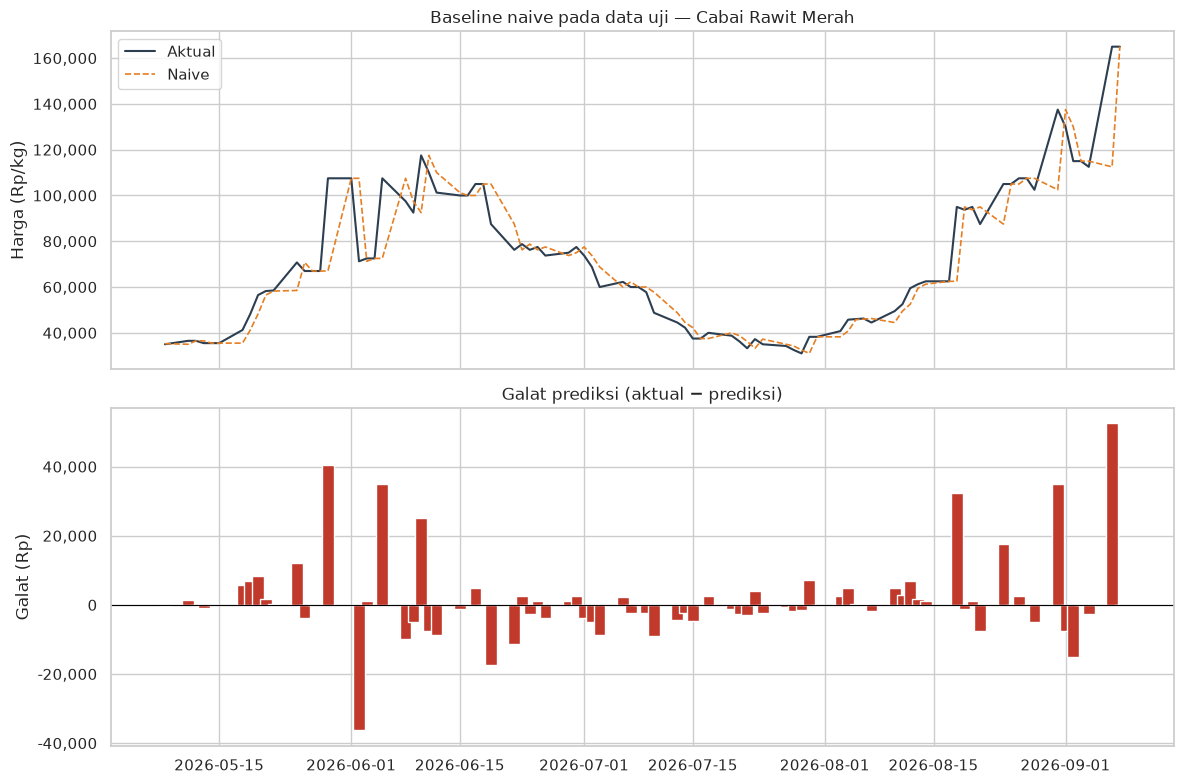

5 galat terbesar:
  07 Sep 2026: aktual 165,000, prediksi 112,500, selisih +52,500
  29 May 2026: aktual 107,500, prediksi 67,000, selisih +40,500
  02 Jun 2026: aktual 71,250, prediksi 107,500, selisih -36,250
  05 Jun 2026: aktual 107,500, prediksi 72,500, selisih +35,000
  31 Aug 2026: aktual 137,500, prediksi 102,500, selisih +35,000


In [3]:
pred_naive = seri.shift(1).loc[uji.index]
galat = uji - pred_naive

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(uji.index, uji.values, label="Aktual", color="#2c3e50", linewidth=1.5)
ax1.plot(uji.index, pred_naive.values, label="Naive", color="#e67e22",
         linewidth=1.2, linestyle="--")
ax1.set_title(f"Baseline naive pada data uji — {TARGET}")
ax1.set_ylabel("Harga (Rp/kg)")
ax1.yaxis.set_major_formatter(lambda x, p: f"{x:,.0f}")
ax1.legend()

ax2.bar(uji.index, galat.values, color="#c0392b", width=1.5)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title("Galat prediksi (aktual − prediksi)")
ax2.set_ylabel("Galat (Rp)")
ax2.yaxis.set_major_formatter(lambda x, p: f"{x:,.0f}")

plt.tight_layout()
plt.show()

print("5 galat terbesar:")
besar = galat.abs().sort_values(ascending=False).head(5)
for tgl in besar.index:
    print(f"  {tgl:%d %b %Y}: aktual {uji[tgl]:,.0f}, prediksi {pred_naive[tgl]:,.0f}, "
          f"selisih {galat[tgl]:+,.0f}")

In [4]:
from sklearn.ensemble import HistGradientBoostingRegressor

def buat_fitur(s):
    d = pd.DataFrame({"harga": s})
    for n in [1, 2, 3, 4, 5, 7]:
        d[f"lag_{n}"] = s.shift(n)
    d["ma_3"] = s.shift(1).rolling(3).mean()
    d["ma_7"] = s.shift(1).rolling(7).mean()
    d["std_7"] = s.shift(1).rolling(7).std()
    d["delta_1"] = s.shift(1) - s.shift(2)
    d["delta_3"] = s.shift(1) - s.shift(4)
    d["rasio_ma"] = s.shift(1) / d["ma_7"]
    d["hari_minggu"] = s.index.dayofweek
    return d.dropna()

fitur = buat_fitur(seri)
X = fitur.drop(columns=["harga"])
y = fitur["harga"]

batas_m = int(len(fitur) * 0.8)
X_latih, X_uji = X.iloc[:batas_m], X.iloc[batas_m:]
y_latih, y_uji = y.iloc[:batas_m], y.iloc[batas_m:]

model = HistGradientBoostingRegressor(
    max_iter=300, learning_rate=0.05, max_depth=4, random_state=42
)
model.fit(X_latih, y_latih)
pred_ml = pd.Series(model.predict(X_uji), index=X_uji.index)

# baseline naive pada periode uji yang sama
naive_sama = seri.shift(1).loc[y_uji.index]

print(f"Periode uji: {y_uji.index.min():%d %b %Y} s/d {y_uji.index.max():%d %b %Y}")
print(f"Jumlah obs : {len(y_uji)}\n")
print(f"{'Model':<25} {'MAE (Rp)':>12} {'MAPE (%)':>10}")
print("-" * 49)
print(f"{'Naive (harga kemarin)':<25} {mae(y_uji, naive_sama):>12,.0f} {mape(y_uji, naive_sama):>10.2f}")
print(f"{'HistGradientBoosting':<25} {mae(y_uji, pred_ml):>12,.0f} {mape(y_uji, pred_ml):>10.2f}")

Periode uji: 11 May 2026 s/d 08 Sep 2026
Jumlah obs : 87

Model                         MAE (Rp)   MAPE (%)
-------------------------------------------------
Naive (harga kemarin)            6,190       7.71
HistGradientBoosting             8,969      10.01


In [5]:
def buat_fitur_delta(s):
    ret = s.pct_change() * 100          # target: perubahan harian dalam persen
    d = pd.DataFrame({"target": ret})
    for n in [1, 2, 3, 4, 5, 7]:
        d[f"ret_lag_{n}"] = ret.shift(n)
    d["ret_ma_3"] = ret.shift(1).rolling(3).mean()
    d["ret_ma_7"] = ret.shift(1).rolling(7).mean()
    d["ret_std_7"] = ret.shift(1).rolling(7).std()
    d["rasio_ma7"] = s.shift(1) / s.shift(1).rolling(7).mean()
    d["rasio_ma30"] = s.shift(1) / s.shift(1).rolling(30).mean()
    d["hari_minggu"] = s.index.dayofweek
    d["harga_kemarin"] = s.shift(1)
    return d.dropna()

fd = buat_fitur_delta(seri)
Xd = fd.drop(columns=["target", "harga_kemarin"])
yd = fd["target"]
harga_kemarin = fd["harga_kemarin"]

batas_d = int(len(fd) * 0.8)
Xd_latih, Xd_uji = Xd.iloc[:batas_d], Xd.iloc[batas_d:]
yd_latih, yd_uji = yd.iloc[:batas_d], yd.iloc[batas_d:]
hk_uji = harga_kemarin.iloc[batas_d:]

model_d = HistGradientBoostingRegressor(
    max_iter=300, learning_rate=0.05, max_depth=4, random_state=42
)
model_d.fit(Xd_latih, yd_latih)

ret_pred = model_d.predict(Xd_uji)
pred_delta = hk_uji * (1 + ret_pred / 100)     # kembalikan ke satuan harga

y_asli = seri.loc[Xd_uji.index]
naive_d = seri.shift(1).loc[Xd_uji.index]

print(f"Periode uji: {y_asli.index.min():%d %b %Y} s/d {y_asli.index.max():%d %b %Y}")
print(f"Jumlah obs : {len(y_asli)}\n")
print(f"{'Model':<28} {'MAE (Rp)':>12} {'MAPE (%)':>10}")
print("-" * 52)
print(f"{'Naive':<28} {mae(y_asli, naive_d):>12,.0f} {mape(y_asli, naive_d):>10.2f}")
print(f"{'HGB — target level':<28} {mae(y_uji, pred_ml):>12,.0f} {mape(y_uji, pred_ml):>10.2f}")
print(f"{'HGB — target perubahan':<28} {mae(y_asli, pred_delta):>12,.0f} {mape(y_asli, pred_delta):>10.2f}")

print(f"\nRentang harga latih : {seri.iloc[:batas_d].min():,.0f} – {seri.iloc[:batas_d].max():,.0f}")
print(f"Rentang harga uji   : {y_asli.min():,.0f} – {y_asli.max():,.0f}")

Periode uji: 18 May 2026 s/d 08 Sep 2026
Jumlah obs : 82

Model                            MAE (Rp)   MAPE (%)
----------------------------------------------------
Naive                               6,537       8.09
HGB — target level                  8,969      10.01
HGB — target perubahan              6,979       8.91

Rentang harga latih : 24,750 – 125,000
Rentang harga uji   : 31,000 – 165,000


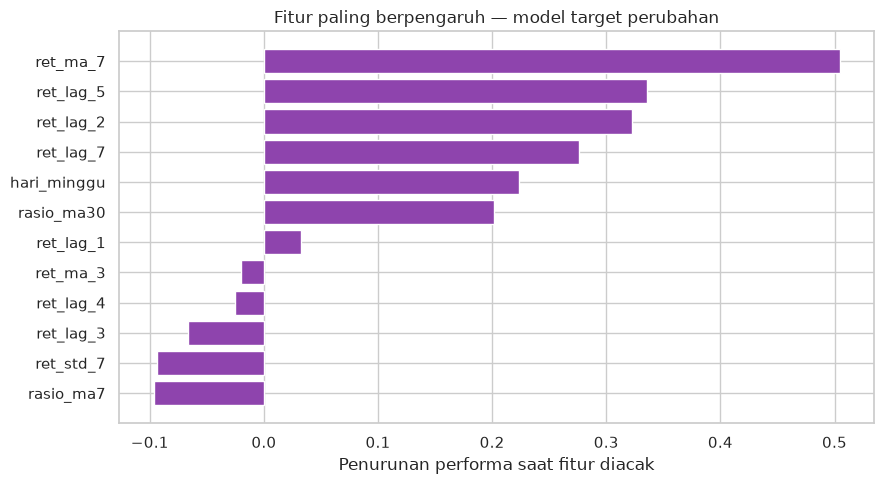

ret_ma_7       0.5045
ret_lag_5      0.3353
ret_lag_2      0.3226
ret_lag_7      0.2760
hari_minggu    0.2232
rasio_ma30     0.2019
ret_lag_1      0.0323
ret_ma_3      -0.0200
ret_lag_4     -0.0249
ret_lag_3     -0.0665
ret_std_7     -0.0938
rasio_ma7     -0.0967


In [6]:
from sklearn.inspection import permutation_importance

imp = permutation_importance(
    model_d, Xd_uji, yd_uji, n_repeats=10, random_state=42, scoring="neg_mean_absolute_error"
)
pentingnya = (
    pd.Series(imp.importances_mean, index=Xd_uji.columns)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(pentingnya.index, pentingnya.values, color="#8e44ad")
ax.invert_yaxis()
ax.set_title("Fitur paling berpengaruh — model target perubahan")
ax.set_xlabel("Penurunan performa saat fitur diacak")
plt.tight_layout()
plt.show()

print(pentingnya.round(4).to_string())

In [7]:
Xd_kecil = Xd[["ret_lag_1", "ret_lag_2", "rasio_ma30"]]
Xk_latih, Xk_uji = Xd_kecil.iloc[:batas_d], Xd_kecil.iloc[batas_d:]

model_k = HistGradientBoostingRegressor(
    max_iter=100, learning_rate=0.03, max_depth=2,
    min_samples_leaf=30, l2_regularization=1.0, random_state=42
)
model_k.fit(Xk_latih, yd_latih)

pred_k = hk_uji * (1 + model_k.predict(Xk_uji) / 100)

print(f"{'Model':<28} {'MAE (Rp)':>12} {'MAPE (%)':>10}")
print("-" * 52)
print(f"{'Naive':<28} {mae(y_asli, naive_d):>12,.0f} {mape(y_asli, naive_d):>10.2f}")
print(f"{'HGB — target level':<28} {mae(y_uji, pred_ml):>12,.0f} {mape(y_uji, pred_ml):>10.2f}")
print(f"{'HGB — perubahan, 12 fitur':<28} {mae(y_asli, pred_delta):>12,.0f} {mape(y_asli, pred_delta):>10.2f}")
print(f"{'HGB — perubahan, 3 fitur':<28} {mae(y_asli, pred_k):>12,.0f} {mape(y_asli, pred_k):>10.2f}")

Model                            MAE (Rp)   MAPE (%)
----------------------------------------------------
Naive                               6,537       8.09
HGB — target level                  8,969      10.01
HGB — perubahan, 12 fitur           6,979       8.91
HGB — perubahan, 3 fitur            6,682       8.39


## Kesimpulan

Baseline naive (prediksi = harga kemarin) tidak berhasil dikalahkan
oleh model gradient boosting pada data ini.

| Model | MAE (Rp) | MAPE (%) |
|---|---|---|
| Naive | 6.537 | 8,09 |
| HGB — target level harga | 8.969 | 10,01 |
| HGB — target perubahan, 12 fitur | 6.979 | 8,91 |
| HGB — target perubahan, 3 fitur | 6.682 | 8,39 |

**Kenapa model level gagal total.** Model berbasis pohon tidak bisa
mengekstrapolasi di luar rentang data latih. Harga latih maksimum
125.000, sementara data uji mencapai 165.000. Model secara struktural
tidak mampu memprediksi angka itu.

**Kenapa 12 fitur kalah dari 3 fitur.** Permutation importance
menunjukkan model bersandar pada `ret_ma_7` dan mengabaikan
`ret_lag_1`, padahal lag_1 adalah sinyal terkuat (korelasi 0,939).
Beberapa fitur bernilai negatif — mengacaknya justru memperbaiki
prediksi. Dengan 349 baris latih, 12 fitur terlalu banyak.

**Kenapa naive sulit dikalahkan.** Korelasi lag_1 sebesar 0,939
berarti sekitar 88% variasi harga besok sudah terjelaskan oleh harga
hari ini. Sisa 12% sebagian besar berupa guncangan pasokan yang
tidak meninggalkan jejak pada data harga saja.

**Batasan.** Periode uji mencakup lonjakan terbesar dalam seluruh
data (September 2026, masih berlangsung saat data diambil). Hanya
satu komoditas dan satu kota yang diuji. Kesimpulan ini belum tentu
berlaku untuk komoditas dengan volatilitas rendah.

**Arah lanjutan yang masuk akal.** Menambah variabel eksternal
(curah hujan, hari libur nasional, data produksi) lebih menjanjikan
daripada mengoprek model — keterbatasannya ada pada informasi yang
tersedia, bukan pada algoritmanya.